### AE_Testing
The goal of this notebook is going to be to see what the output of the pipeline would look like if we used images or sounds

In [1]:
import sys
import os 
from pathlib import Path

sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from src.models import GMSKAutoEncoder
import torch
from src.modulation import gmsk_mod, gmsk_demod, differential_decode, differential_encode
from src.channel import awgn

In [3]:
# Global Parameters
BT = 0.3
Tb = 10
L = 16
k = 4

fc = 146e6

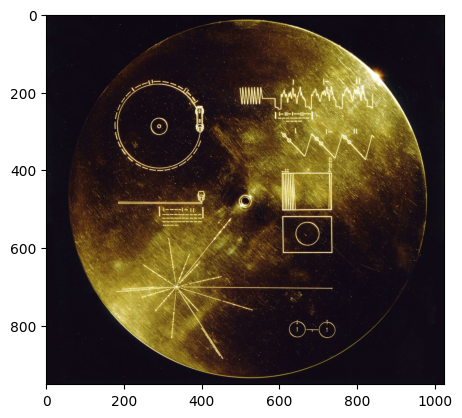

In [14]:
data_path = Path.cwd().parent / "Data"

img = mpimg.imread(data_path / "input_img.jpg")

plt.imshow(img)

if img.dtype != np.uint8:
    img = (img*255).astype(np.uint8)

height = img.shape[0]
width = img.shape[1]
channels = img.shape[2]

# Flatten data to send it through the signal
bits = np.unpackbits(img.flatten())

In [5]:
print(bits.shape)

(23371776,)


In [6]:
model = GMSKAutoEncoder()

save_path = Path.cwd().parent / "weights" / "AE_model.pth"

print(f"--- Loading weights from {save_path} ---")
# Load the state dictionary into the model
model.load_state_dict(torch.load(save_path, weights_only=True))
model.eval() # Set to evaluation mode

--- Loading weights from c:\Users\charl\OneDrive\Bureau\Cubesat-Radioastronomie\weights\AE_model.pth ---


GMSKAutoEncoder(
  (encoder): Sequential(
    (0): Conv1d(2, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(32, 16, kernel_size=(2,), stride=(2,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
    (3): Conv1d(16, 8, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Tanh()
    (6): Conv1d(8, 2, kernel_size=(3,), stride=(1,), padding=(1,))
  )
)

In [50]:
# Way too many bits, but we can process through batches: 
BATCH_SIZE = 2**11
received_bits_noisy = []
received_bits_denoised = []
received_bits_clean = []
sig_len = len(bits)

for i in range(0, sig_len, BATCH_SIZE):
    batch = bits[i:i+BATCH_SIZE].astype(int)
    
    _, s_clean = gmsk_mod(batch, fc, L, BT)
    s_noisy = awgn(s_clean, 3) # 3dBd SNR

    input_tensor = torch.from_numpy(np.vstack((s_noisy.real, s_noisy.imag))).float().unsqueeze(0)
    with torch.no_grad():
        denoised_iq_raw = model(input_tensor).squeeze(0).numpy()
    denoised_iq = denoised_iq_raw[0, :] + 1j * denoised_iq_raw[1, :]

    received_bits_noisy.append(gmsk_demod(s_noisy, L))
    received_bits_denoised.append(gmsk_demod(denoised_iq, L))
    received_bits_clean.append(gmsk_demod(s_clean, L))

In [51]:
bits_noisy = np.concatenate(received_bits_noisy)
bits_denoised = np.concatenate(received_bits_denoised)

In [52]:
bytes_noisy = np.packbits(bits_noisy)
bytes_denoised = np.packbits(bits_denoised)

In [53]:
img_output = bytes_noisy[:height*width*channels].reshape(height, width, channels)
img_output_denoised = bytes_denoised[:height*width*channels].reshape(height, width, channels)

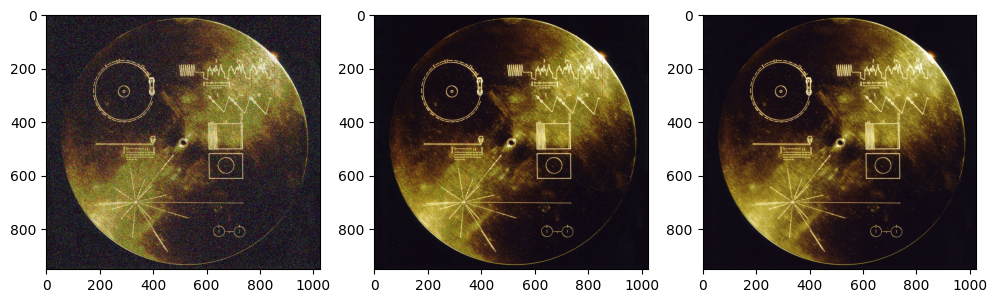

In [54]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.imshow(img_output)
ax2.imshow(img_output_denoised)
ax3.imshow(img)